# Lab 6: K-Nearest Neighbor and SVM Classification
## Objective
Build K-Nearest Neighbor and SVM classification models and evaluate their performance using appropriate metrics.

**Dataset:** Seeds Dataset (Wheat Varieties) — `seeds_dataset.csv`

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 2. Load and Prepare Data

In [2]:
df = pd.read_csv('seeds_dataset.csv')

feature_cols = df.columns[:-1]
X = df[feature_cols]
y = df['Class']
class_names = ['Kama', 'Rosa', 'Canadian']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for KNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train.shape[0]} samples")
print(f"Testing:  {X_test.shape[0]} samples")

Training: 168 samples
Testing:  42 samples


---
## Part A: K-Nearest Neighbors (KNN)

### 3. Finding Optimal K

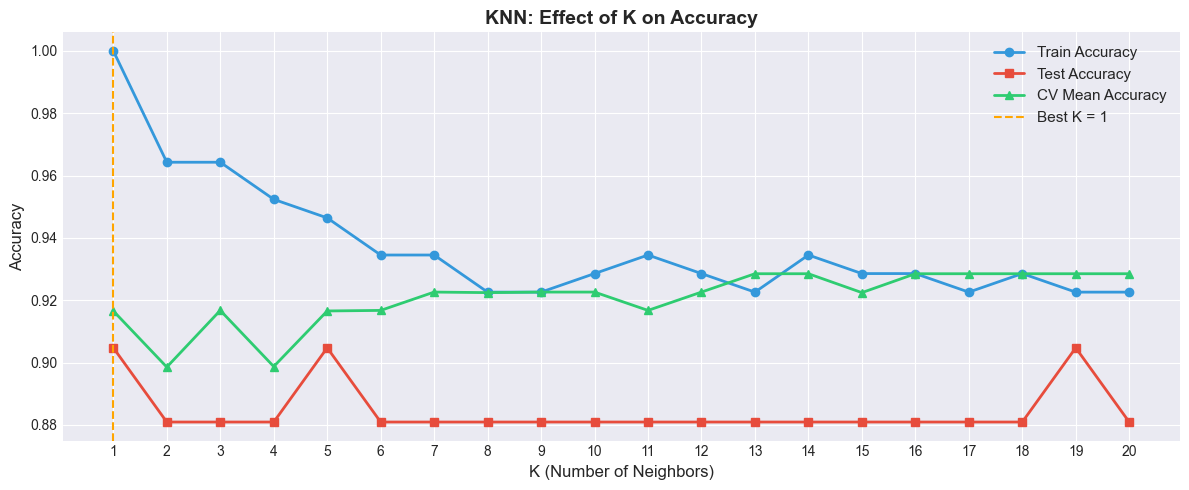

Best K: 1 (Test Accuracy: 0.9048)


In [3]:
# Test different K values
k_values = range(1, 21)
train_scores = []
test_scores = []
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))
    cv = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_values, train_scores, 'o-', label='Train Accuracy', color='#3498db', linewidth=2)
ax.plot(k_values, test_scores, 's-', label='Test Accuracy', color='#e74c3c', linewidth=2)
ax.plot(k_values, cv_scores, '^-', label='CV Mean Accuracy', color='#2ecc71', linewidth=2)

best_k = k_values[np.argmax(test_scores)]
ax.axvline(x=best_k, color='orange', linestyle='--', linewidth=1.5, label=f'Best K = {best_k}')

ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('KNN: Effect of K on Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(k_values))
plt.tight_layout()
plt.show()

print(f"Best K: {best_k} (Test Accuracy: {max(test_scores):.4f})")

### 4. Train KNN with Optimal K

In [4]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

print(f"KNN Model (K={best_k})")
print("=" * 45)
print(f"Metric: {knn_model.metric}")
print(f"Weights: {knn_model.weights}")

KNN Model (K=1)
Metric: minkowski
Weights: uniform


### 5. Evaluate KNN

In [5]:
y_pred_knn = knn_model.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average='weighted')
rec_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print("KNN — Evaluation Metrics")
print("=" * 45)
print(f"Accuracy:  {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall:    {rec_knn:.4f}")
print(f"F1 Score:  {f1_knn:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=class_names))

KNN — Evaluation Metrics
Accuracy:  0.9048
Precision: 0.9190
Recall:    0.9048
F1 Score:  0.9007

Classification Report:
              precision    recall  f1-score   support

        Kama       1.00      0.71      0.83        14
        Rosa       0.93      1.00      0.97        14
    Canadian       0.82      1.00      0.90        14

    accuracy                           0.90        42
   macro avg       0.92      0.90      0.90        42
weighted avg       0.92      0.90      0.90        42



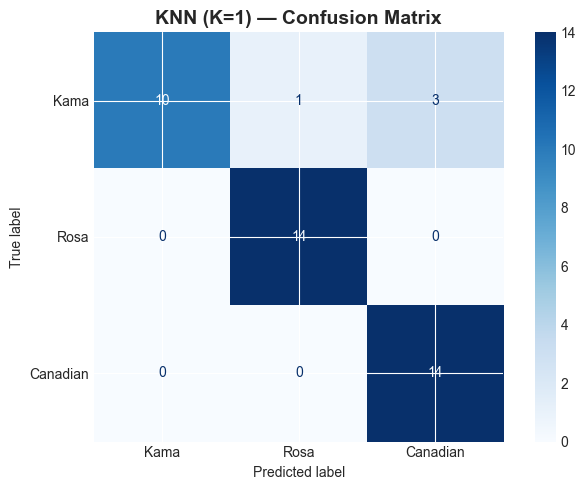

In [6]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'KNN (K={best_k}) — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. KNN with Different Distance Metrics

In [7]:
metrics = ['euclidean', 'manhattan', 'minkowski']
results_metrics = []

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results_metrics.append({'Metric': metric, 'Accuracy': acc})

pd.DataFrame(results_metrics)

,Metric,Accuracy
0,euclidean,0.904762
1,manhattan,0.857143
2,minkowski,0.904762


---
## Part B: Support Vector Machine (SVM)

### 7. Train SVM with Different Kernels

In [8]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
svm_results = []

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    svm_results.append({
        'Kernel': kernel,
        'Accuracy': acc,
        'F1 Score': f1
    })

svm_comparison = pd.DataFrame(svm_results)
print("SVM Performance with Different Kernels:")
svm_comparison

SVM Performance with Different Kernels:


,Kernel,Accuracy,F1 Score
0,linear,0.880952,0.873056
1,rbf,0.904762,0.900000
2,poly,0.880952,0.882405
3,sigmoid,0.880952,0.873056


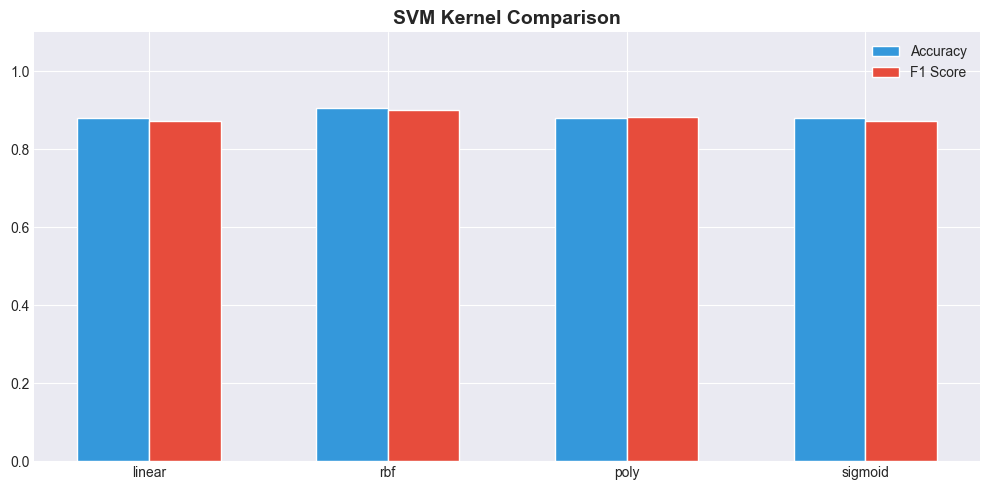

In [9]:
# Visualize kernel comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(kernels))
width = 0.3

ax.bar(x - width/2, svm_comparison['Accuracy'], width, label='Accuracy',
       color='#3498db', edgecolor='white')
ax.bar(x + width/2, svm_comparison['F1 Score'], width, label='F1 Score',
       color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(kernels)
ax.set_ylim(0, 1.1)
ax.set_title('SVM Kernel Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 8. Train Best SVM Model

In [10]:
# Use the best kernel
best_kernel = svm_comparison.loc[svm_comparison['Accuracy'].idxmax(), 'Kernel']
print(f"Best kernel: {best_kernel}")

svm_model = SVC(kernel=best_kernel, random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)

print(f"\nSVM Model ({best_kernel} kernel)")
print("=" * 45)
print(f"Number of support vectors: {svm_model.n_support_}")
print(f"Total support vectors: {sum(svm_model.n_support_)}")

Best kernel: rbf

SVM Model (rbf kernel)
Number of support vectors: [24 15 21]
Total support vectors: 60


### 9. Evaluate SVM

In [11]:
y_pred_svm = svm_model.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average='weighted')
rec_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

print("SVM — Evaluation Metrics")
print("=" * 45)
print(f"Accuracy:  {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall:    {rec_svm:.4f}")
print(f"F1 Score:  {f1_svm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

SVM — Evaluation Metrics
Accuracy:  0.9048
Precision: 0.9167
Recall:    0.9048
F1 Score:  0.9000

Classification Report:
              precision    recall  f1-score   support

        Kama       1.00      0.71      0.83        14
        Rosa       0.88      1.00      0.93        14
    Canadian       0.88      1.00      0.93        14

    accuracy                           0.90        42
   macro avg       0.92      0.90      0.90        42
weighted avg       0.92      0.90      0.90        42



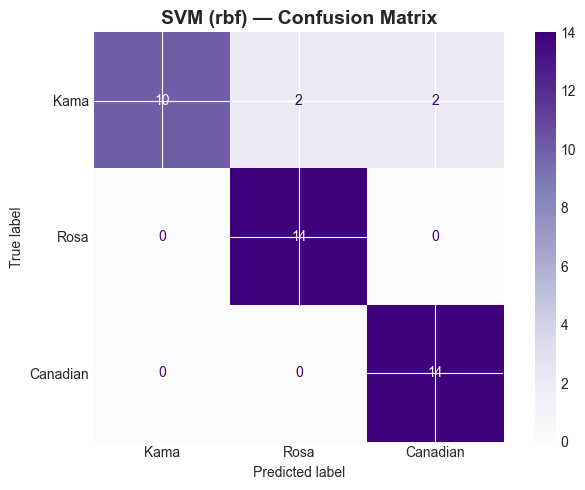

In [12]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_names)
disp.plot(cmap='Purples', ax=ax)
ax.set_title(f'SVM ({best_kernel}) — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10. SVM Hyperparameter Tuning (GridSearchCV)

In [13]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5,
                           scoring='accuracy', n_jobs=-1, verbose=0)
grid_search.fit(X_train_scaled, y_train)

print("GridSearchCV Results")
print("=" * 45)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
y_pred_tuned = grid_search.predict(X_test_scaled)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Test Accuracy (tuned): {acc_tuned:.4f}")

GridSearchCV Results
Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score: 0.9640
Test Accuracy (tuned): 0.9286


## 11. Model Comparison

In [14]:
# Cross-validation for both models
cv_knn = cross_val_score(knn_model, scaler.transform(X), y, cv=5, scoring='accuracy')
cv_svm = cross_val_score(svm_model, scaler.transform(X), y, cv=5, scoring='accuracy')

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'CV Mean Accuracy'],
    f'KNN (K={best_k})': [acc_knn, prec_knn, rec_knn, f1_knn, cv_knn.mean()],
    f'SVM ({best_kernel})': [acc_svm, prec_svm, rec_svm, f1_svm, cv_svm.mean()]
})

print("Model Comparison")
print("=" * 55)
comparison

Model Comparison


,Metric,KNN (K=1),SVM (rbf)
0,Accuracy,0.904762,0.904762
1,Precision,0.918954,0.916667
2,Recall,0.904762,0.904762
3,F1 Score,0.900692,0.900000
4,CV Mean Accuracy,0.914286,0.914286


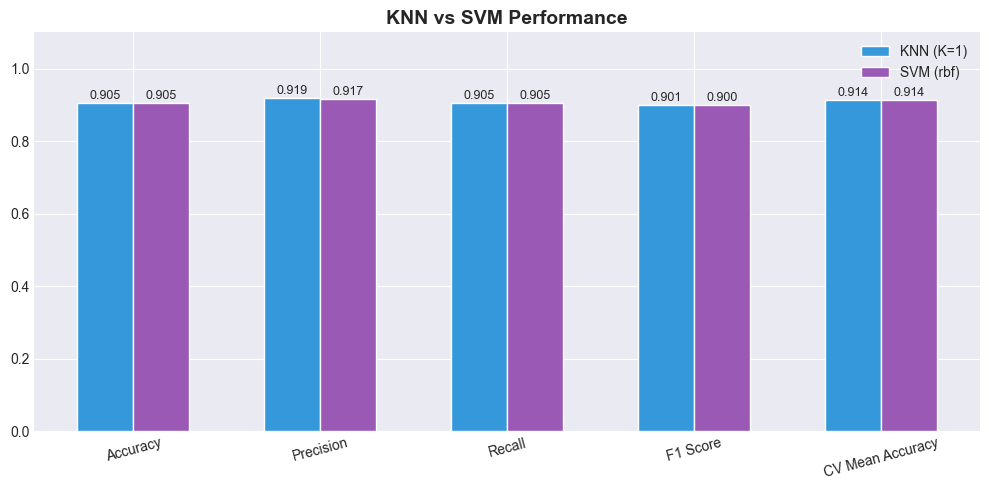

In [15]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.3

bars1 = ax.bar(x - width/2, comparison.iloc[:, 1], width, label=f'KNN (K={best_k})',
               color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, comparison.iloc[:, 2], width, label=f'SVM ({best_kernel})',
               color='#9b59b6', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(comparison['Metric'], rotation=15)
ax.set_ylim(0, 1.1)
ax.set_title('KNN vs SVM Performance', fontsize=14, fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 12. Conclusion
In this lab, we:
- **KNN**: Tested multiple K values; found optimal K through elbow method. Feature scaling is critical for distance-based methods.
- **SVM**: Compared multiple kernels (linear, RBF, polynomial, sigmoid). Used GridSearchCV for hyperparameter tuning.
- Both models perform well on the Seeds dataset.
- SVM with RBF/linear kernel typically achieves high accuracy due to good class separability.